In [1]:
cd C:\R_projects\mothz\detectron2\custom_training

C:\R_projects\mothz\detectron2\custom_training


In [2]:
import torch, detectron2, cv2
!nvcc --version
print("\nTorch CUDA version:", torch.version.cuda)
print("\nTorch version:", torch.__version__)
print("\ndetectron2:", detectron2.__version__)
print("\ncv2 version:",cv2.__version__)


nvcc: NVIDIA (R) Cuda compiler driver
Copyright (c) 2005-2023 NVIDIA Corporation
Built on Fri_Sep__8_19:56:38_Pacific_Daylight_Time_2023
Cuda compilation tools, release 12.3, V12.3.52
Build cuda_12.3.r12.3/compiler.33281558_0

Torch CUDA version: 12.1

Torch version: 2.1.1

detectron2: 0.6

cv2 version: 4.11.0


In [3]:
print("Python version: ")
!python --version

Python version: 
Python 3.8.20


In [4]:
# Some basic setup:
# Setup detectron2 logger
from detectron2.utils.logger import setup_logger
setup_logger()
import numpy as np
import os, json, cv2, random
from detectron2 import model_zoo
from detectron2.engine import DefaultPredictor,DefaultTrainer
from detectron2.config import get_cfg
from detectron2.data import MetadataCatalog, DatasetCatalog
from detectron2.data.datasets import register_coco_instances
from detectron2.utils.visualizer import ColorMode,GenericMask,Visualizer
from detectron2.structures.keypoints import heatmaps_to_keypoints
from matplotlib import pyplot as plt
import glob
from detectron2.data import build_detection_test_loader
from detectron2.evaluation import (
    CityscapesInstanceEvaluator,
    CityscapesSemSegEvaluator,
    COCOEvaluator,
    COCOPanopticEvaluator,
    LVISEvaluator,
    PascalVOCDetectionEvaluator,
    SemSegEvaluator,
    DatasetEvaluator,
    inference_on_dataset,
    print_csv_format,
    verify_results,
)

In [5]:
from detectron2.custom.misc import *
from detectron2.custom.parse_ruler_tags import *

In [6]:
# Register datasets and populate metadata
register_coco_instances("beetle_train", {}, "./beetle/coco_beetle_train.json", "C:/R_projects/mothz/coco-annotator/datasets/beetle")
register_coco_instances("beetle_test", {}, "./beetle/coco_beetle_test.json", "C:/R_projects/mothz/coco-annotator/datasets/beetle")

In [7]:
things = ["beetle"]
things_color = [(255, 0, 0)]

MetadataCatalog.get("beetle_train").set(thing_classes=things)
MetadataCatalog.get("beetle_train").set(thing_colors=things_color)

MetadataCatalog.get("beetle_test").set(thing_classes=things)
MetadataCatalog.get("beetle_test").set(thing_colors=things_color)

namespace(name='beetle_test',
          json_file='./beetle/coco_beetle_test.json',
          image_root='C:/R_projects/mothz/coco-annotator/datasets/beetle',
          evaluator_type='coco',
          thing_classes=['beetle'],
          thing_colors=[(255, 0, 0)])

In [8]:
# Set model configs
cfg = get_cfg()
cfg.merge_from_file(model_zoo.get_config_file("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml"))
cfg.DATASETS.TRAIN = ("beetle_train",)
cfg.DATASETS.TEST = ("beetle_test", ) # Called test in detectron2, but is actually the validation data
cfg.MODEL.WEIGHTS = model_zoo.get_checkpoint_url("COCO-Detection/faster_rcnn_R_50_FPN_3x.yaml")  # Let training initialize from model zoo
cfg.DATALOADER.NUM_WORKERS = 2
cfg.DATALOADER.FILTER_EMPTY_ANNOTATIONS = False 
cfg.TEST.EVAL_PERIOD = 0 # Turn off COCO evluator. 
cfg.SOLVER.IMS_PER_BATCH = 2  # This is the real "batch size" commonly known to deep learning people
cfg.SOLVER.BASE_LR = 0.0001  
cfg.SOLVER.MAX_ITER = 400    
cfg.SOLVER.LR_SCHEDULER_NAME = "WarmupCosineLR"
cfg.SOLVER.WARMUP_ITERS = 100
cfg.MODEL.ROI_HEADS.BATCH_SIZE_PER_IMAGE = 128   # The "RoIHead batch size"
cfg.MODEL.ROI_HEADS.NUM_CLASSES = len(things) # Change for the number of classes
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.03 # Set to lower?
cfg.TEST.DETECTIONS_PER_IMAGE = 10 # Set higher to allow filtering by class later
cfg.SOLVER.CHECKPOINT_PERIOD = 100
cfg.MODEL.ROI_KEYPOINT_HEAD.NUM_KEYPOINTS = 0
cfg.TEST.KEYPOINT_OKS_SIGMAS = []
cfg.INPUT.RANDOM_FLIP = "horizontal"
cfg.MODEL.MASK_ON = False
cfg.MODEL.KEYPOINT_ON = False # Keypoint detection for multiple thing classes not supported by detectron2
cfg.MODEL.ROI_KEYPOINT_HEAD.LOSS_WEIGHT = 5
cfg.MODEL.ROI_KEYPOINT_HEAD.NORMALIZE_LOSS_BY_VISIBLE_KEYPOINTS = False
cfg.OUTPUT_DIR = "./beetle/model"
#cfg.MODEL.BACKBONE.FREEZE_AT = 0
cfg.INPUT.MAX_SIZE_TEST = 2000
cfg.INPUT.MAX_SIZE_TRAIN = 2000
cfg.INPUT.MIN_SIZE_TEST = 2000
cfg.INPUT.MIN_SIZE_TRAIN = 2000

# cfg.MODEL.RPN.PRE_NMS_TOPK_TRAIN = 5000
#cfg.MODEL.RPN.PRE_NMS_TOPK_TEST = 3000
#cfg.MODEL.RPN.POST_NMS_TOPK_TRAIN = 2500
#cfg.MODEL.RPN.POST_NMS_TOPK_TEST = 2000
cfg.MODEL.RPN.NMS_THRESH = 0.9


os.makedirs(cfg.OUTPUT_DIR, exist_ok=True)

In [9]:
print(cfg)

CUDNN_BENCHMARK: False
DATALOADER:
  ASPECT_RATIO_GROUPING: True
  FILTER_EMPTY_ANNOTATIONS: False
  NUM_WORKERS: 2
  REPEAT_SQRT: True
  REPEAT_THRESHOLD: 0.0
  SAMPLER_TRAIN: TrainingSampler
DATASETS:
  PRECOMPUTED_PROPOSAL_TOPK_TEST: 1000
  PRECOMPUTED_PROPOSAL_TOPK_TRAIN: 2000
  PROPOSAL_FILES_TEST: ()
  PROPOSAL_FILES_TRAIN: ()
  TEST: ('beetle_test',)
  TRAIN: ('beetle_train',)
FLOAT32_PRECISION: 
GLOBAL:
  HACK: 1.0
INPUT:
  CROP:
    ENABLED: False
    SIZE: [0.9, 0.9]
    TYPE: relative_range
  FORMAT: BGR
  MASK_FORMAT: polygon
  MAX_SIZE_TEST: 2000
  MAX_SIZE_TRAIN: 2000
  MIN_SIZE_TEST: 2000
  MIN_SIZE_TRAIN: 2000
  MIN_SIZE_TRAIN_SAMPLING: choice
  RANDOM_FLIP: horizontal
MODEL:
  ANCHOR_GENERATOR:
    ANGLES: [[-90, 0, 90]]
    ASPECT_RATIOS: [[0.5, 1.0, 2.0]]
    NAME: DefaultAnchorGenerator
    OFFSET: 0.0
    SIZES: [[32], [64], [128], [256], [512]]
  BACKBONE:
    FREEZE_AT: 2
    NAME: build_resnet_fpn_backbone
  DEVICE: cuda
  FPN:
    FUSE_TYPE: sum
    IN_FEATURES

In [ ]:
### Train model
trainer = CustomTrainer(cfg)
trainer.resume_or_load(resume=True)
trainer.train()

In [ ]:
# Look at model performance over iterations
%load_ext tensorboard
#%reload_ext tensorboard
%tensorboard --logdir "C:/R_projects/mothz/detectron2/custom_training/beetle/model"

### Go to directroy to delete temp file if TensorBoard fails to launch
# !del /S C:\Users\vsbpa\AppData\Local\Temp\.tensorboard-info

In [10]:
# Load fitted model as predictor
cfg.MODEL.WEIGHTS = os.path.join(cfg.OUTPUT_DIR, "model_0000199.pth")
cfg.MODEL.ROI_HEADS.SCORE_THRESH_TEST = 0.5  # set to 0.3 for now, but actually filtered to 0.7 in R
predictor = DefaultPredictor(cfg)

[04/08 14:05:19 d2.checkpoint.detection_checkpoint]: [DetectionCheckpointer] Loading from ./beetle/model\model_0000199.pth ...


C:\Users\vsbpa\.conda\envs\mothz\lib\site-packages\torch\functional.py:504: UserWarning: torch.meshgrid: in an upcoming release, it will be required to pass the indexing argument. (Triggered internally at C:\cb\pytorch_1000000000000\work\aten\src\ATen\native\TensorShape.cpp:3527.)
  return _VF.meshgrid(tensors, **kwargs)  # type: ignore[attr-defined]


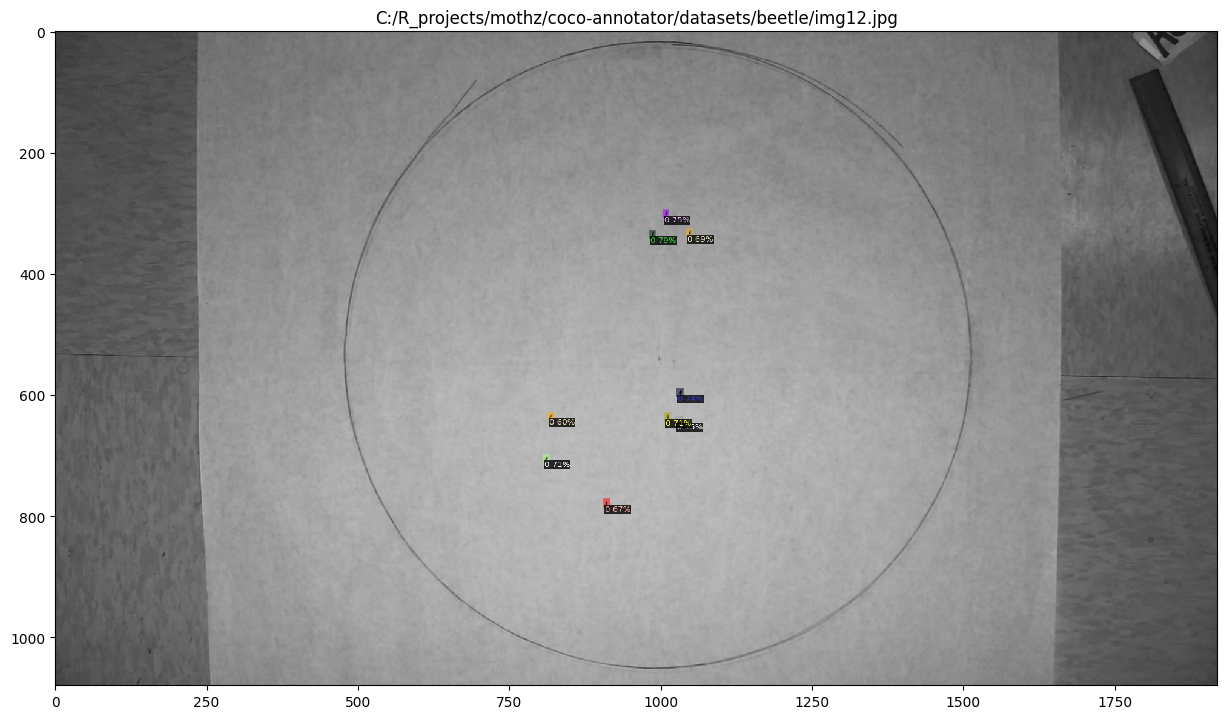

In [11]:
%matplotlib inline 

f = glob.glob("C:/R_projects/mothz/coco-annotator/datasets/beetle/img12.jpg")
fi = random.choice(f)
#fi = f[0]
im = cv2.imread(fi)
outputs = predictor(im)  # format is documented at https://detectron2.readthedocs.io/tutorials/models.html#model-output-format
v = Visualizer(im[:, :, 0:3][:,:,::-1],
                   metadata=MetadataCatalog.get("beetle_tess"), 
                   scale=1, 
               instance_mode=ColorMode.IMAGE_BW
)
outputs = filter_instance_by_classes(outputs, "beetle_test",[10]) # max detection: ['beetle']
out = v.draw_instance_predictions(outputs)


plt.figure(figsize = (15,15))
plt.imshow(out.get_image()[:,:,0:3], interpolation='nearest')
plt.title(fi)
plt.show()

In [12]:
# For writing predictions
from detectron2.custom.writing import *

In [15]:
from detectron2.custom.sort import *
def reformat_instances(outputs): 
    if len(outputs) == 0: 
        return np.empty((0, 5))
    dataset = []
    for i in range(len(outputs)):
        l = outputs.pred_boxes.tensor.tolist()[i] + [outputs.scores.tolist()[i]]
        dataset.append(l)
    return np.array(dataset,  dtype='float64')
def gather_track_results(track_res):
    data = {}
    data["bboxes"] = track_res[:,0:4].tolist()
    data["track_id"] = track_res[:,4].tolist()
    return data
def track_video(video_path, write_path, predictor, meta, max_detection):
    video_capture = cv2.VideoCapture(video_path)
    total_frames = int(video_capture.get(cv2.CAP_PROP_FRAME_COUNT))
    width = int(video_capture.get(cv2.CAP_PROP_FRAME_WIDTH))
    height = int(video_capture.get(cv2.CAP_PROP_FRAME_HEIGHT))
    fps = video_capture.get(cv2.CAP_PROP_FPS)
    frame_count = 0
    dataset = []
    mot_tracker = Sort()
    while True:
        success, frame = video_capture.read()
        frame_count = frame_count + 1
        if not success:
            bn = os.path.splitext(os.path.basename(video_path))[0]
            write_csv(os.path.join(write_path, bn + "_track" + ".csv"), dataset)
            break
        outputs = predictor(frame)
        outputs = filter_instance_by_classes(outputs, meta, max_detection)
        track_res = mot_tracker.update(reformat_instances(outputs))
        data = gather_track_results(track_res)
        data["frame"] = frame_count
        data["width"] = width
        data["height"] = height
        data["fps"] = fps
        data["path"] = video_path
        dataset.append(data)
        print(f"Processed frame {frame_count} out of {total_frames}. {round(frame_count/total_frames, 2) * 100} % complete                                     ", end='\r')
        

In [ ]:
# Perform inference on the training dataset
write_img_inference(
    predictor, 
    write_path = "C:/R_projects/mothz/",
    name = "beetle_detection",
    read_path = "C:/R_projects/mothz/beetle_image_stack/", 
    model_ver = "modelv1.0",
    meta = "beetle_train",
    max_detection = [10], 
    mode = "bbox"
    )

In [16]:
track_video("C:/R_projects/mothz/AC_10out.mp4",
           "C:/R_projects/mothz/",
           predictor, 
           "beetle_train",
           [10])